# Laptop Price Prediction — Exploratory Data Analysis
**Dataset:** `laptop_master.csv` — merged from 4 real-world sources
**Rows:** 3,918 | **Columns:** 10
**Target variable:** `price` (INR)

## 1. Setup & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [ ]:
df = pd.read_csv('laptop_master.csv')
print('Shape:', df.shape)
df.head()

Shape: (3918, 10)


,source,brand,processor,gpu,ram_gb,ram_type,storage_gb,storage_type,os,price
0,ds01,HP,5th Gen AMD Ryzen 5 5600H,4GB AMD Radeon RX 6500M,8,DDR4,512,SSD,Windows 11,49900
1,ds01,HP,12th Gen Intel Core i3 1215U,Intel UHD Graphics,8,DDR4,512,SSD,Windows 11,39900
2,ds01,Acer,11th Gen Intel Core i3 1115G4,Intel Iris Xe Graphics,8,DDR4,512,SSD,Windows 11,26990
3,ds01,Lenovo,12th Gen Intel Core i5 1240P,Intel Integrated Iris Xe,16,LPDDR5,512,SSD,Windows 11,59729
4,ds01,Apple,Apple M1,Apple M1 Integrated Graphics,8,DDR4,256,SSD,macOS,69990


## 2. Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3918 entries, 0 to 3917
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   source        3918 non-null   object
 1   brand         3918 non-null   object
 2   processor     3918 non-null   object
 3   gpu           3918 non-null   object
 4   ram_gb        3918 non-null   int64 
 5   ram_type      3918 non-null   object
 6   storage_gb    3918 non-null   int64 
 7   storage_type  3918 non-null   object
 8   os            3918 non-null   object
 9   price         3918 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 306.2+ KB


In [ ]:
df.describe().round(2)

,ram_gb,storage_gb,price
count,3918.00,3918.00,3918.00
mean,12.62,583.49,97552.72
std,7.40,355.56,72799.45
min,2.00,8.00,8000.00
25%,8.00,500.00,49990.00
50%,12.00,512.00,74343.50
75%,16.00,512.00,121903.00
max,96.00,4096.00,664425.00


In [ ]:
# Null check
print('Null values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Null values per column:
source          0
brand           0
processor       0
gpu             0
ram_gb          0
ram_type        0
storage_gb      0
storage_type    0
os              0
price           0
dtype: int64

Duplicate rows: 0


**Insight:** The dataset contains no null values and no duplicate rows — a result of the per-source cleaning and deduplication performed before merging. All numeric columns (`price`, `ram_gb`, `storage_gb`) are correctly typed as integers.

## 3. Target Variable — Price Distribution

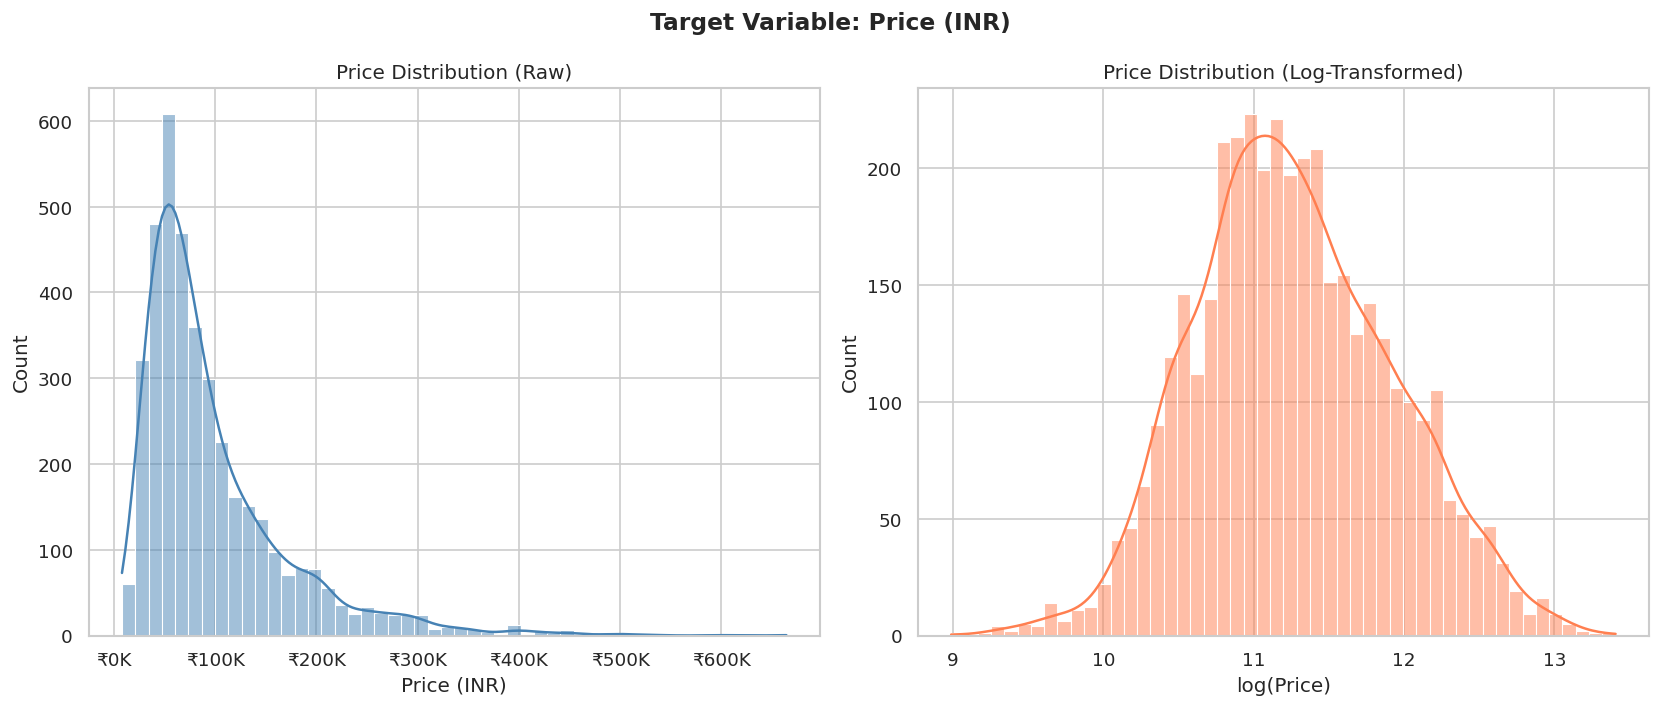

Skewness (raw):        2.079
Skewness (log):        0.183
Price range:           ₹8,000 — ₹664,425
Median price:          ₹74344


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw price
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (INR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Log-transformed price
sns.histplot(np.log1p(df['price']), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Target Variable: Price (INR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness (raw):        {df["price"].skew():.3f}')
print(f'Skewness (log):        {np.log1p(df["price"]).skew():.3f}')
print(f'Price range:           ₹{df["price"].min():,} — ₹{df["price"].max():,}')
print(f'Median price:          ₹{df["price"].median():.0f}')

**Insight:** Price is heavily right-skewed (skew = 2.079), which is expected for consumer electronics — most laptops cluster in the ₹50K–₹1.2L range, with a long tail of premium models reaching ₹6.6L. The log-transformed distribution is near-normal, suggesting that models trained on `log(price)` will likely perform better. The target variable should be log-transformed before modeling.

## 4. Numeric Features vs Price

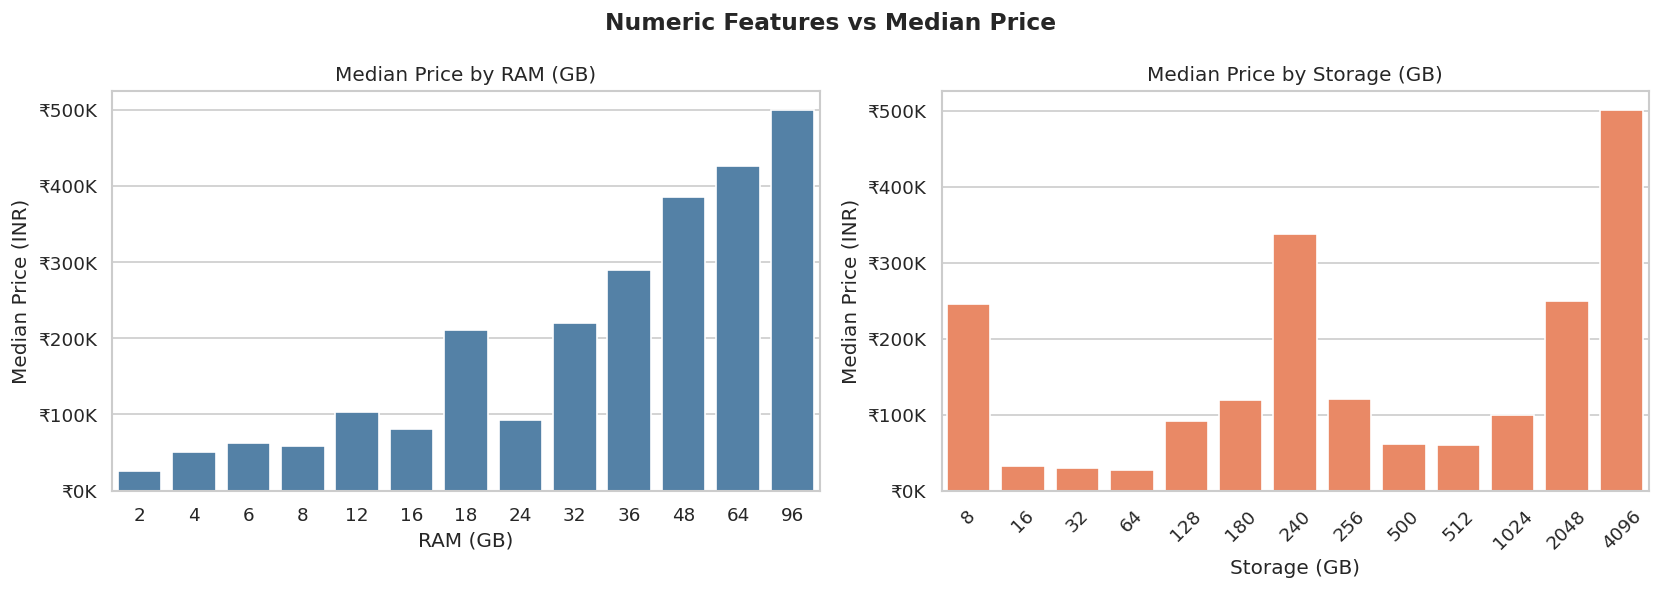

Correlation with price:
ram_gb        0.561
storage_gb    0.290
Name: price, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RAM vs price
ram_price = df.groupby('ram_gb')['price'].median().reset_index()
sns.barplot(data=ram_price, x='ram_gb', y='price', ax=axes[0], color='steelblue')
axes[0].set_title('Median Price by RAM (GB)')
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Median Price (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Storage vs price
stor_price = df.groupby('storage_gb')['price'].median().reset_index()
sns.barplot(data=stor_price, x='storage_gb', y='price', ax=axes[1], color='coral')
axes[1].set_title('Median Price by Storage (GB)')
axes[1].set_xlabel('Storage (GB)')
axes[1].set_ylabel('Median Price (INR)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.suptitle('Numeric Features vs Median Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with price:')
print(df[['ram_gb', 'storage_gb', 'price']].corr()['price'].drop('price').round(3))

**Insight:** `ram_gb` has a strong positive correlation with price (r = 0.56) and shows a clear monotonic trend — higher RAM consistently means higher price. `storage_gb` has a weaker correlation (r = 0.29), partly because storage type (SSD vs HDD) matters as much as size. Both features are important for the model, but RAM is likely to be a stronger predictor.

## 5. Categorical Features vs Price

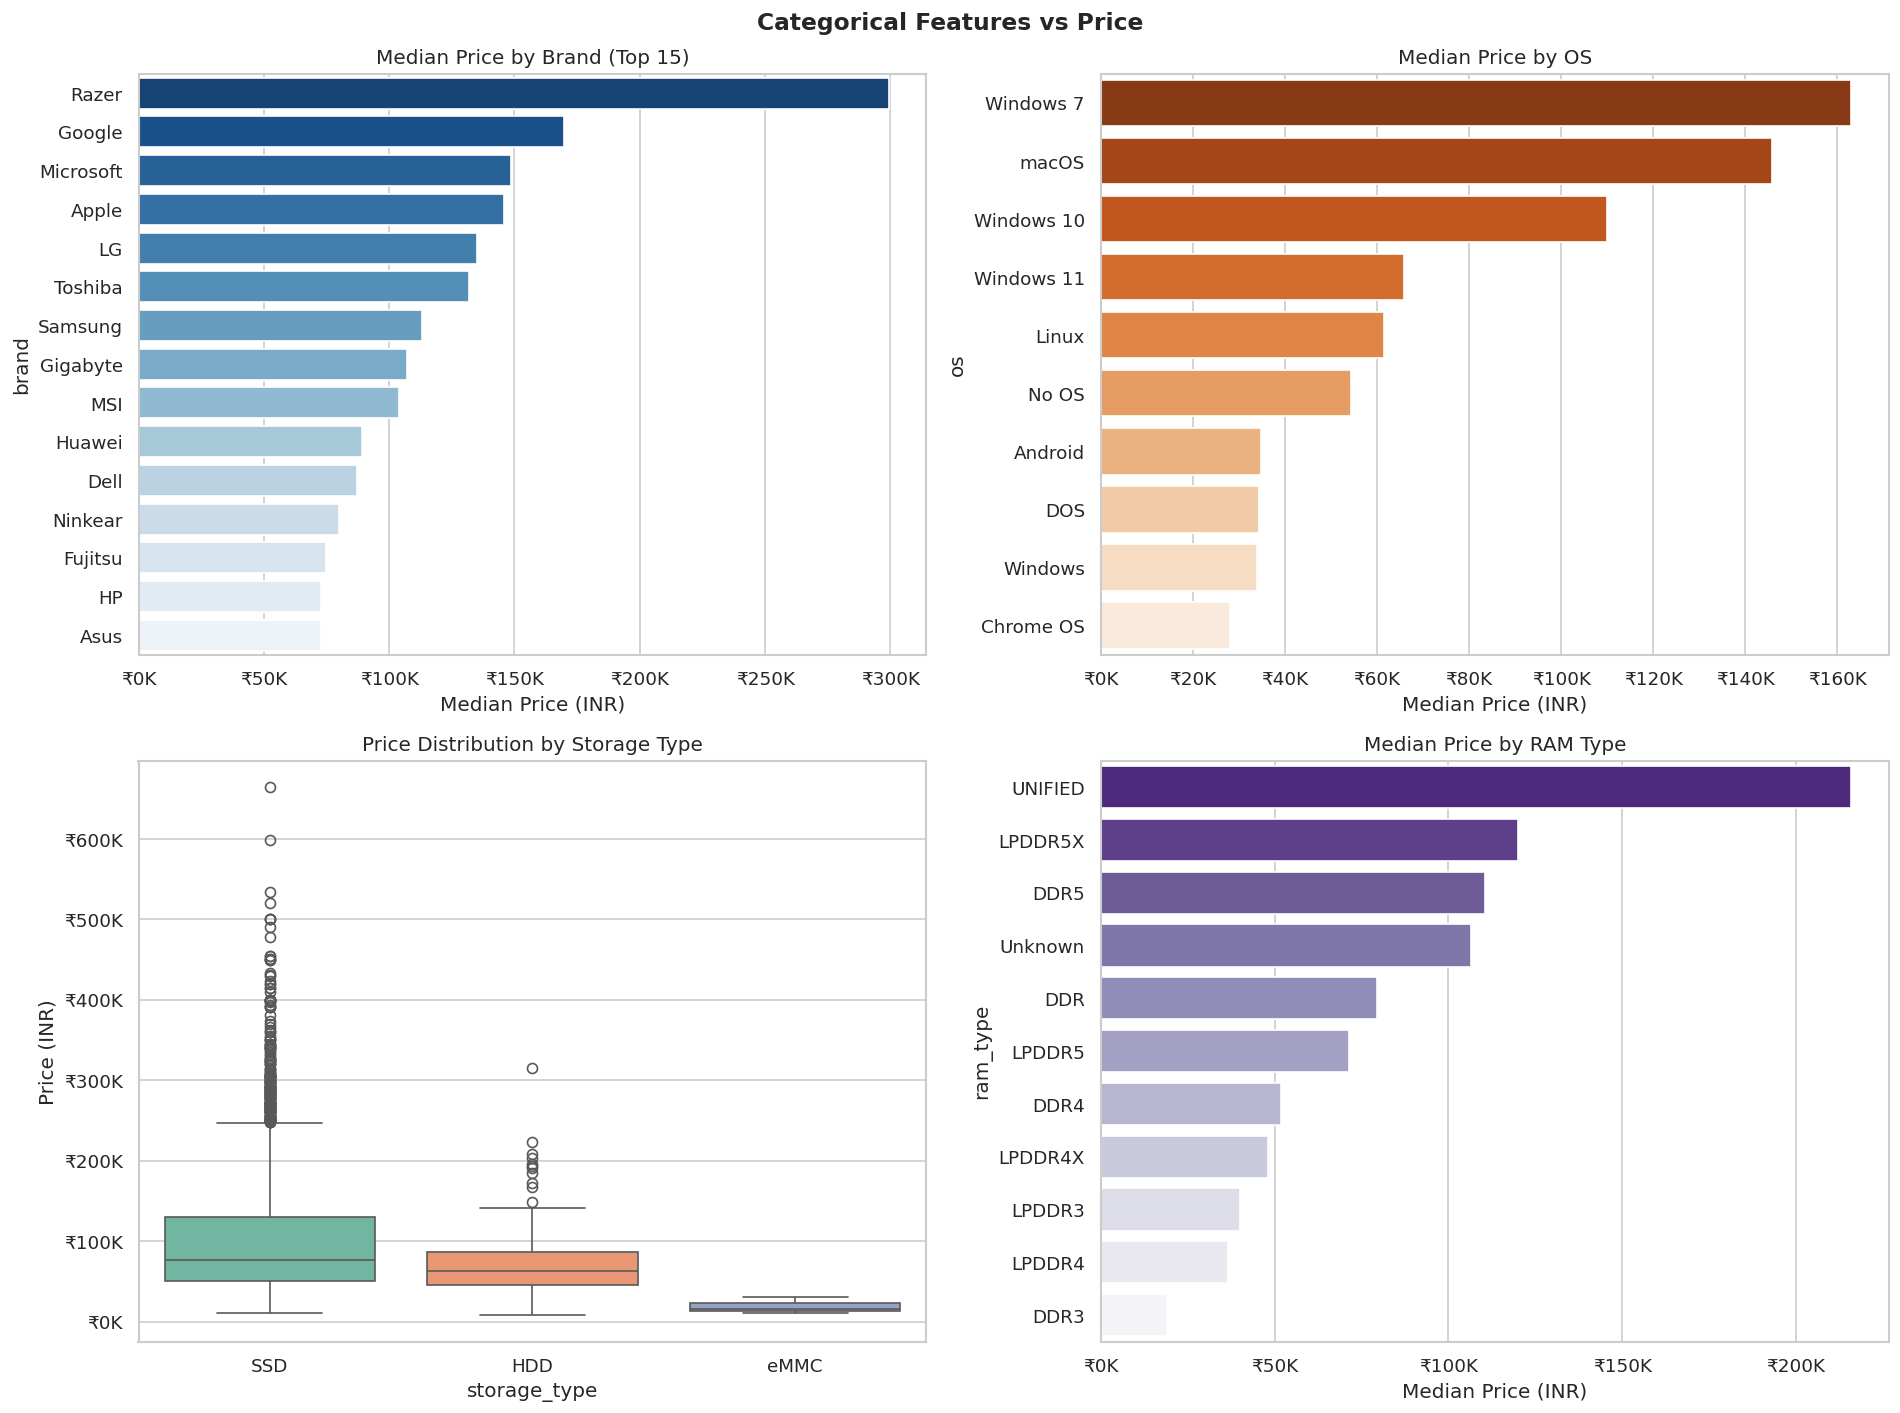

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Brand vs median price (top 15)
brand_price = df.groupby('brand')['price'].median().sort_values(ascending=False).head(15)
sns.barplot(x=brand_price.values, y=brand_price.index, ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Median Price by Brand (Top 15)')
axes[0,0].set_xlabel('Median Price (INR)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# OS vs median price
os_price = df.groupby('os')['price'].median().sort_values(ascending=False)
sns.barplot(x=os_price.values, y=os_price.index, ax=axes[0,1], palette='Oranges_r')
axes[0,1].set_title('Median Price by OS')
axes[0,1].set_xlabel('Median Price (INR)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Storage type vs price (boxplot)
sns.boxplot(data=df, x='storage_type', y='price', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Price Distribution by Storage Type')
axes[1,0].set_ylabel('Price (INR)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# RAM type vs median price
ramtype_price = df.groupby('ram_type')['price'].median().sort_values(ascending=False)
sns.barplot(x=ramtype_price.values, y=ramtype_price.index, ax=axes[1,1], palette='Purples_r')
axes[1,1].set_title('Median Price by RAM Type')
axes[1,1].set_xlabel('Median Price (INR)')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.suptitle('Categorical Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Brand is a strong price signal — Razer, Apple, Microsoft, and Google command a significant premium over budget brands like AXL, Primebook, or Zebronics. OS also correlates with price but largely reflects the brand (macOS = Apple = premium). Storage type shows eMMC laptops are the cheapest (mostly Chromebooks/tablets), while SSDs and HDDs occupy overlapping mid-to-high ranges. Newer RAM standards (DDR5, LPDDR5X) are associated with higher prices than older DDR4, as expected.

## 6. Outlier Detection

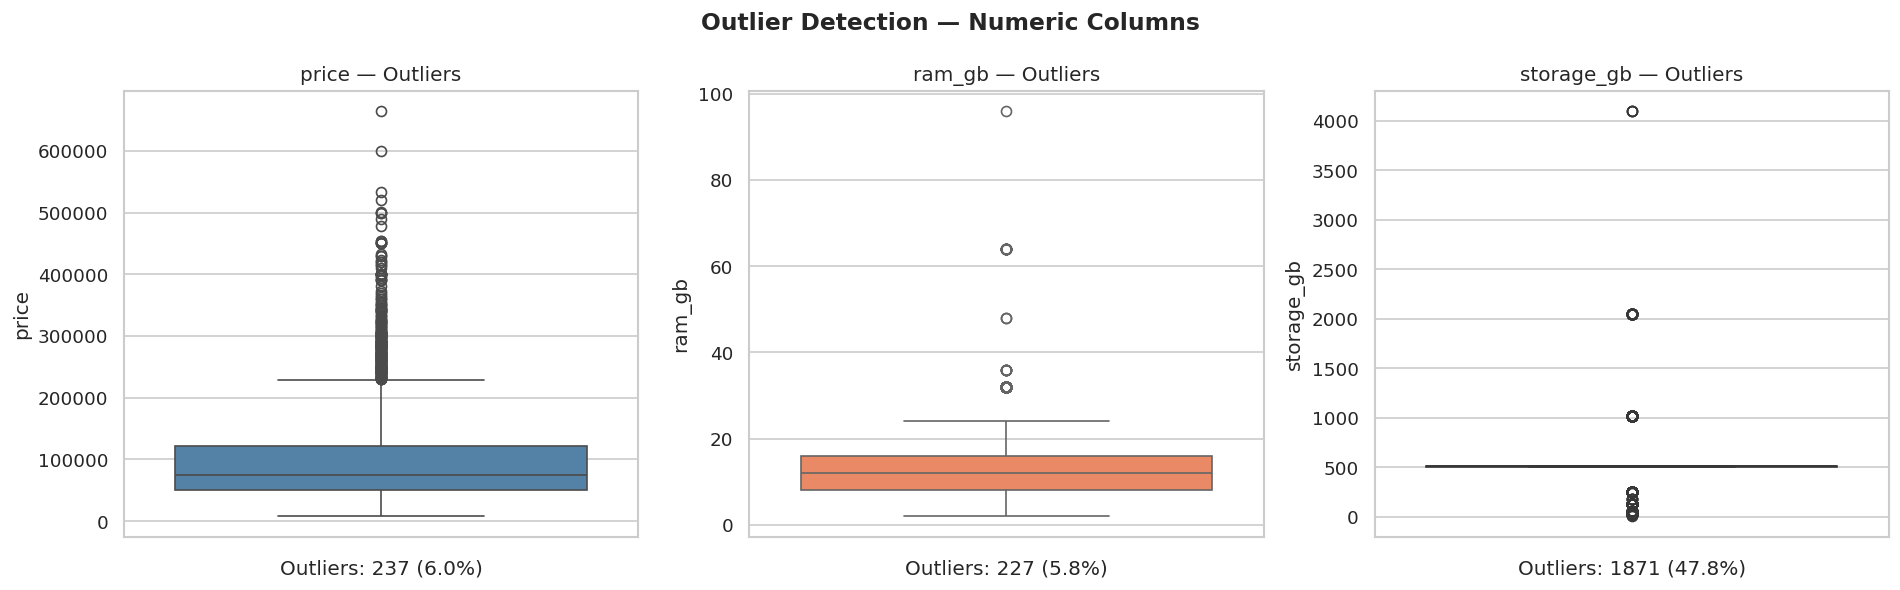

price: 237 outliers (6.0%)
ram_gb: 227 outliers (5.8%)
storage_gb: 1871 outliers (47.8%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['price', 'ram_gb', 'storage_gb'], ['steelblue', 'coral', 'seagreen']):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f'{col} — Outliers')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    ax.set_xlabel(f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

plt.suptitle('Outlier Detection — Numeric Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR summary
for col in ['price', 'ram_gb', 'storage_gb']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f'{col}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

**Insight:** Price has the most outliers by IQR definition, but these are genuine premium laptops (Razer, Apple M-series, workstations), not data errors — dropping them would bias the model against the premium segment. RAM and storage outliers (e.g. 64GB RAM, 4TB storage) are similarly real high-end configurations. The recommendation is to keep all outliers and instead rely on log-transformation of the target variable to reduce their leverage.

## 7. Correlation Heatmap

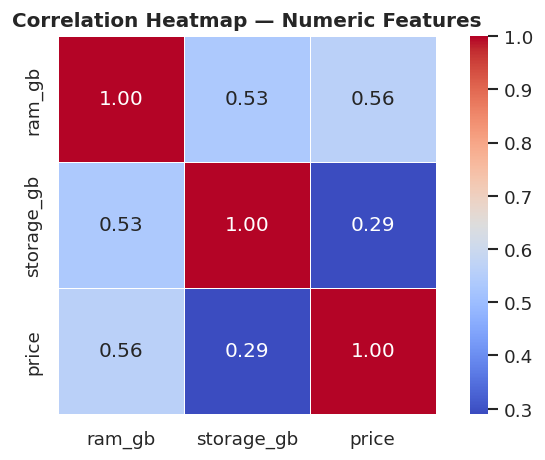

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
numeric_cols = ['ram_gb', 'storage_gb', 'price']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** `ram_gb` and `storage_gb` have low inter-feature correlation (no multicollinearity risk), so both can be used together safely. `ram_gb` has the stronger relationship with price (0.56 vs 0.29), confirming it as the most important numeric predictor.

## 8. Source Distribution Check

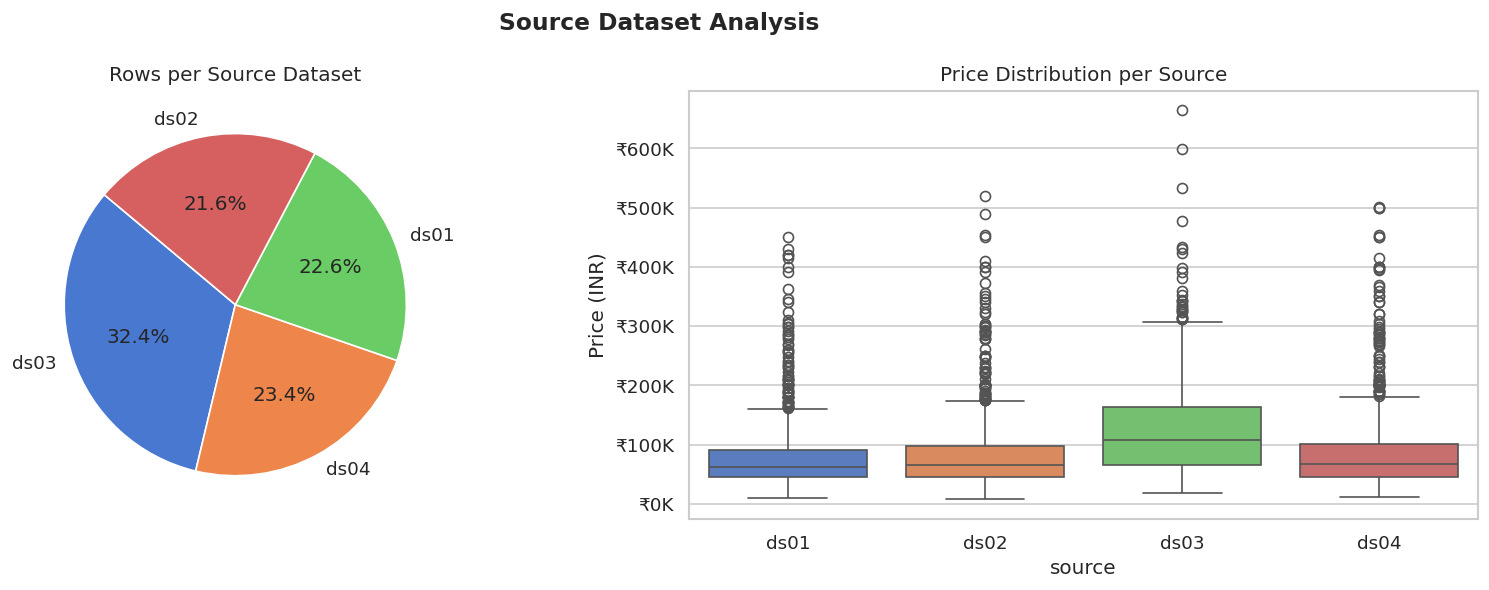

         count      mean      std      min      25%       50%       75%  \
source                                                                    
ds01     885.0   80086.0  61074.0   9999.0  44690.0   61990.0   90990.0   
ds02     846.0   85438.0  67962.0   8000.0  45990.0   65990.0   97000.0   
ds03    1269.0  123757.0  76442.0  18955.0  66344.0  107632.0  163192.0   
ds04     918.0   89332.0  72516.0  10990.0  45990.0   67390.0  100142.0   

             max  
source            
ds01    450039.0  
ds02    519990.0  
ds03    664425.0  
ds04    500990.0  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Row count per source
src_counts = df['source'].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(src_counts)))
axes[0].set_title('Rows per Source Dataset')

# Price distribution per source
sns.boxplot(data=df, x='source', y='price', ax=axes[1], palette='muted')
axes[1].set_title('Price Distribution per Source')
axes[1].set_ylabel('Price (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.suptitle('Source Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('source')['price'].describe().round(0))

**Insight:** ds03 contributes the most rows (1,270) and also has the widest price range — it contains older Euro-converted entries including high-end workstations. ds01 and ds02 are both INR-native and more concentrated in the ₹25K–₹1.5L consumer range. This source imbalance is worth noting during modeling — the `source` column can be dropped before training since it is metadata, not a product feature.

## 9. EDA Summary — Key Findings

| # | Finding | Modeling Implication |
|---|---|---|
| 1 | Price is heavily right-skewed (skew = 2.079) | Apply `log1p(price)` as target variable |
| 2 | `ram_gb` is the strongest numeric predictor (r = 0.56) | Keep as-is; scale before linear models |
| 3 | `storage_gb` has moderate correlation (r = 0.29) | Keep; pair with `storage_type` for full signal |
| 4 | Brand strongly differentiates price segments | Encode with target encoding or ordinal by median price |
| 5 | OS partly redundant with brand (macOS = Apple) | Keep but watch for multicollinearity with brand |
| 6 | `ram_type = Unknown` for 1,351 rows (ds03) | Treat Unknown as its own category; do not impute |
| 7 | Rare OS values: Windows 7, Android, DOS | Group into 'Other' before encoding |
| 8 | Outliers are genuine premium products | Keep all; log-transform handles leverage |
| 9 | `processor` and `gpu` have 400+ unique values | Extract brand/tier from string rather than one-hot encoding raw values |
| 10 | `source` column is metadata only | Drop before training |